In [126]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [127]:
# matrix = np.array([
#     [0, 1, 1, 0],
#     [1, 0, 1, 1],
#     [1, 1, 0, 1],
#     [0, 1, 1, 0]
# ])

matrix = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])

In [128]:
G = nx.from_numpy_array(matrix)

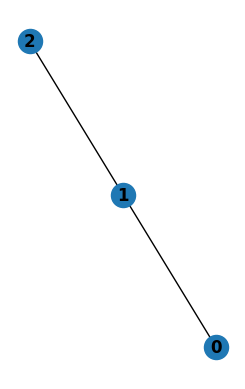

In [129]:
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold')

In [130]:
G.nodes

NodeView((0, 1, 2))

In [131]:
G.edges

EdgeView([(0, 1), (1, 2)])

In [132]:
adj = nx.to_numpy_array(G)

In [133]:
adj

array([[0., 1., 0.],
       [1., 0., 1.],
       [0., 1., 0.]])

In [134]:
eigenvalues, eigenvectors = np.linalg.eig(adj)

In [135]:
eigenvalues, eigenvectors

(array([-1.41421356e+00,  9.77950360e-17,  1.41421356e+00]),
 array([[ 5.00000000e-01,  7.07106781e-01,  5.00000000e-01],
        [-7.07106781e-01,  9.06753788e-17,  7.07106781e-01],
        [ 5.00000000e-01, -7.07106781e-01,  5.00000000e-01]]))

In [136]:
diag = np.diag(eigenvalues)
diag

array([[-1.41421356e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  9.77950360e-17,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.41421356e+00]])

In [150]:
diag * diag

array([[2.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 9.56386906e-33, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 2.00000000e+00]])

In [137]:
X = np.concat(eigenvectors)
X

array([ 5.00000000e-01,  7.07106781e-01,  5.00000000e-01, -7.07106781e-01,
        9.06753788e-17,  7.07106781e-01,  5.00000000e-01, -7.07106781e-01,
        5.00000000e-01])

In [138]:
adj == np.transpose(adj)

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [139]:
adj.shape

(3, 3)

In [140]:
incidence_mat = np.zeros((len(list(G.nodes)), len(list(G.edges))), dtype=int)

for i, edge in enumerate(G.edges):
    v1, v2 = edge
    incidence_mat[v1, i] = 1
    incidence_mat[v2, i] = 1

incidence_mat

array([[1, 0],
       [1, 1],
       [0, 1]])

In [141]:
degrees = np.sum(adj, axis=1)
degree_mat = np.diag(degrees)
degree_mat

array([[1., 0., 0.],
       [0., 2., 0.],
       [0., 0., 1.]])

In [142]:
C = np.dot(incidence_mat, np.transpose(incidence_mat)) - degree_mat
C

array([[0., 1., 0.],
       [1., 0., 1.],
       [0., 1., 0.]])

In [143]:
adj == C

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [144]:
degree_mat - adj == np.dot(incidence_mat, np.transpose(incidence_mat))

array([[ True, False,  True],
       [False,  True, False],
       [ True, False,  True]])

In [145]:
A = degree_mat - adj
B = np.dot(incidence_mat, np.transpose(incidence_mat))
print(A)
print(B)

[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]
[[1 1 0]
 [1 2 1]
 [0 1 1]]


In [ ]:
line =  eigenvalues * eigenvectors
line

array([[-7.07106781e-01,  6.91515331e-17,  7.07106781e-01],
       [ 1.00000000e+00,  8.86760193e-33,  1.00000000e+00],
       [-7.07106781e-01, -6.91515331e-17,  7.07106781e-01]])

In [ ]:
line =   eigenvalues * eigenvectors * np.transpose(eigenvalues)
line

array([[ 1.00000000e+00,  6.76267667e-33,  1.00000000e+00],
       [-1.41421356e+00,  8.67207450e-49,  1.41421356e+00],
       [ 1.00000000e+00, -6.76267667e-33,  1.00000000e+00]])